In [1]:
from scipy import stats
from itertools import combinations

def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

def paired_ttest_report(name, a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    a, b = a[mask], b[mask]

    if len(a) < 2:
        return {
            "name": name,
            "n": len(a),
            "t": np.nan,
            "p": np.nan,
            "star": "NA"
        }

    t, p = stats.ttest_rel(a, b)
    return {
        "name": name,
        "n": len(a),
        "mean_a": float(np.mean(a)),
        "mean_b": float(np.mean(b)),
        "t": float(t),
        "p": float(p),
        "star": p_to_star(p)
    }

def welch_ttest_report(name, a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]

    if len(a) < 2 or len(b) < 2:
        return {
            "name": name,
            "n1": len(a),
            "n2": len(b),
            "t": np.nan,
            "p": np.nan,
            "star": "NA"
        }

    t, p = stats.ttest_ind(a, b, equal_var=False)
    return {
        "name": name,
        "n1": len(a),
        "n2": len(b),
        "mean_1": float(np.mean(a)),
        "mean_2": float(np.mean(b)),
        "t": float(t),
        "p": float(p),
        "star": p_to_star(p)
    }

def onesample_ttest_report(name, a, popmean=1.0):
    a = np.asarray(a, dtype=float)
    a = a[np.isfinite(a)]

    if len(a) < 2:
        return {
            "name": name,
            "n": len(a),
            "t": np.nan,
            "p": np.nan,
            "star": "NA"
        }

    t, p = stats.ttest_1samp(a, popmean=popmean)
    return {
        "name": name,
        "n": len(a),
        "mean": float(np.mean(a)),
        "mu0": float(popmean),
        "t": float(t),
        "p": float(p),
        "star": p_to_star(p)
    }

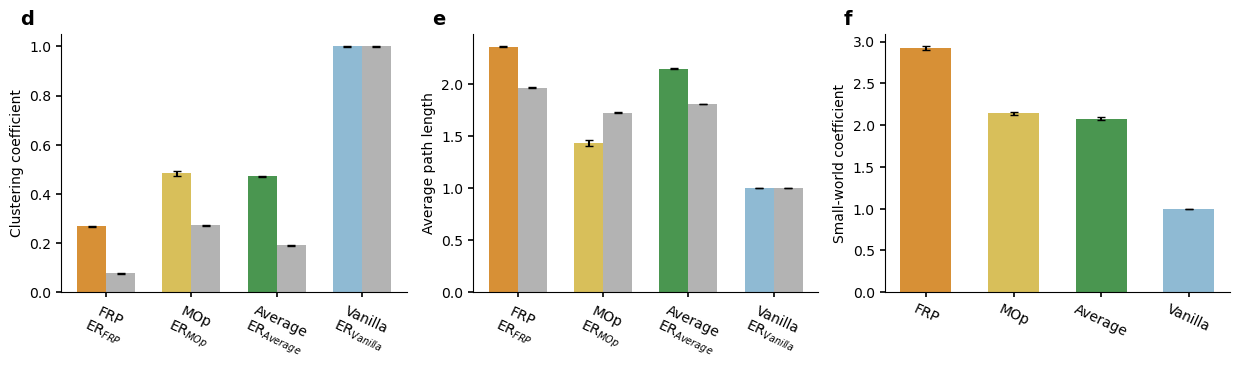


===== Paired t-test: observed vs ER =====
{'name': 'FRP: C vs ER', 'n': 20, 'mean_a': 0.26893098258692444, 'mean_b': 0.07675470116481506, 't': 112.78799132354968, 'p': 2.5477212781062882e-28, 'star': '***'}
{'name': 'FRP: L vs ER', 'n': 20, 'mean_a': 2.3617568002907308, 'mean_b': 1.969490341395548, 't': 101.55781637264573, 'p': 1.8630527328437924e-27, 'star': '***'}
{'name': 'MOp: C vs ER', 'n': 20, 'mean_a': 0.4838075003440827, 'mean_b': 0.2722469633512118, 't': 26.63023464150216, 'p': 1.6557371755332408e-16, 'star': '***'}
{'name': 'MOp: L vs ER', 'n': 20, 'mean_a': 1.4354470670865531, 'mean_b': 1.7277396648727983, 't': -10.311047551463895, 'p': 3.206035865094053e-09, 'star': '***'}
{'name': 'Average: C vs ER', 'n': 20, 'mean_a': 0.47142806123367736, 'mean_b': 0.19083547262701875, 't': 113.7071982451979, 'p': 2.1840845481785727e-28, 'star': '***'}
{'name': 'Average: L vs ER', 'n': 20, 'mean_a': 2.151261887129692, 'mean_b': 1.8091637337940312, 't': 55.00168417556952, 'p': 2.057146392

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ====== 1) 输入文件 ======
jsonl_path = "results_sw_er/swER_all.jsonl"
save_path = "results_sw_er/fig_5def_smallworld.svg"



# ====== 2) 每个网络选一个阈值 ======
chosen_p = {
    "FRP": 0.2,
    "MOp": 0.2,
    "Average": 0.2,
}

net_order = ["FRP", "MOp", "Average"]

colors = {
    "FRP": "#d79036",
    "MOp": "#d8bf5a",
    "Average": "#4a9650",
    "Vanilla": "#8fbad3",
    "ER": "#b3b3b3",
}

# ====== 3) 读数据并筛选 ======
records_by_net = {k: [] for k in net_order}

with open(jsonl_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        rec = json.loads(line)

        net = rec["net_type"]
        if net not in chosen_p:
            continue

        p = float(rec["p_thre"])
        if abs(p - chosen_p[net]) < 1e-9:
            records_by_net[net].append(rec)

# ====== 4) 统计函数：均值 + SEM ======
def mean_sem(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    n = vals.size
    if n == 0:
        return np.nan, np.nan
    if n == 1:
        return float(vals.mean()), 0.0
    sem = vals.std(ddof=1) / np.sqrt(n)
    return float(vals.mean()), float(sem)

# ====== 5) 汇总 ======
C_mean, C_sem = [], []
C_er_mean, C_er_sem = [], []

L_mean, L_sem = [], []
L_er_mean, L_er_sem = [], []

S_mean, S_sem = [], []

for net in net_order:
    recs = records_by_net[net]

    C_obs = [r["sw_er"]["obs"]["C"] for r in recs]
    C_er  = [r["sw_er"]["rand"]["C_mean"] for r in recs]

    L_obs = [r["sw_er"]["obs"]["L"] for r in recs]
    L_er  = [r["sw_er"]["rand"]["L_mean"] for r in recs]

    S_obs = [r["sw_er"]["ratio"]["sigma_CL"] for r in recs]

    m, s = mean_sem(C_obs)
    C_mean.append(m); C_sem.append(s)

    m, s = mean_sem(C_er)
    C_er_mean.append(m); C_er_sem.append(s)

    m, s = mean_sem(L_obs)
    L_mean.append(m); L_sem.append(s)

    m, s = mean_sem(L_er)
    L_er_mean.append(m); L_er_sem.append(s)

    m, s = mean_sem(S_obs)
    S_mean.append(m); S_sem.append(s)

# ====== 6) 补 Vanilla ======
# d/e 中给 Vanilla 和 ER_Vanilla 一对柱子
# 这里只是占位用；如果你有真实 Vanilla 数据，建议替换
vanilla_C = 1.0
vanilla_C_sem = 1e-3
vanilla_C_er = 1.0
vanilla_C_er_sem = 1e-3

vanilla_L = 1.0
vanilla_L_sem = 1e-3
vanilla_L_er = 1.0
vanilla_L_er_sem = 1e-3

# f 中 Vanilla 固定为 1
vanilla_sigma = 1.0
vanilla_sigma_sem = 1e-3

# ====== 7) 画图 ======
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))

group_labels = ["FRP", "MOp", "Average", "Vanilla"]
group_colors = [colors["FRP"], colors["MOp"], colors["Average"], colors["Vanilla"]]

# 每组中心位置
x = np.arange(len(group_labels))
barw = 0.34

# -------- panel d: Clustering coefficient --------
C_obs_all = [C_mean[0], C_mean[1], C_mean[2], vanilla_C]
C_obs_sem_all = [C_sem[0], C_sem[1], C_sem[2], vanilla_C_sem]

C_er_all = [C_er_mean[0], C_er_mean[1], C_er_mean[2], vanilla_C_er]
C_er_sem_all = [C_er_sem[0], C_er_sem[1], C_er_sem[2], vanilla_C_er_sem]

axes[0].bar(
    x - barw/2, C_obs_all, barw,
    yerr=C_obs_sem_all, capsize=3,
    color=group_colors, edgecolor="none"
)
axes[0].bar(
    x + barw/2, C_er_all, barw,
    yerr=C_er_sem_all, capsize=3,
    color=colors["ER"], edgecolor="none"
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    ["FRP\nER$_{FRP}$", "MOp\nER$_{MOp}$", "Average\nER$_{Average}$", "Vanilla\nER$_{Vanilla}$"],
    rotation=-25
)
axes[0].set_ylabel("Clustering coefficient")

# -------- panel e: Average path length --------
L_obs_all = [L_mean[0], L_mean[1], L_mean[2], vanilla_L]
L_obs_sem_all = [L_sem[0], L_sem[1], L_sem[2], vanilla_L_sem]

L_er_all = [L_er_mean[0], L_er_mean[1], L_er_mean[2], vanilla_L_er]
L_er_sem_all = [L_er_sem[0], L_er_sem[1], L_er_sem[2], vanilla_L_er_sem]

axes[1].bar(
    x - barw/2, L_obs_all, barw,
    yerr=L_obs_sem_all, capsize=3,
    color=group_colors, edgecolor="none"
)
axes[1].bar(
    x + barw/2, L_er_all, barw,
    yerr=L_er_sem_all, capsize=3,
    color=colors["ER"], edgecolor="none"
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    ["FRP\nER$_{FRP}$", "MOp\nER$_{MOp}$", "Average\nER$_{Average}$", "Vanilla\nER$_{Vanilla}$"],
    rotation=-25
)
axes[1].set_ylabel("Average path length")

# -------- panel f: Small-world coefficient --------
sigma_labels = ["FRP", "MOp", "Average", "Vanilla"]
sigma_vals = [S_mean[0], S_mean[1], S_mean[2], vanilla_sigma]
sigma_errs = [S_sem[0], S_sem[1], S_sem[2], vanilla_sigma_sem]

axes[2].bar(
    np.arange(len(sigma_labels)), sigma_vals, 0.58,
    yerr=sigma_errs, capsize=3,
    color=[colors[k] for k in sigma_labels],
    edgecolor="none"
)
axes[2].set_xticks(np.arange(len(sigma_labels)))
axes[2].set_xticklabels(sigma_labels, rotation=-25)
axes[2].set_ylabel("Small-world coefficient")

# ====== 8) 美化 ======
for ax, lab in zip(axes, ["d", "e", "f"]):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(width=1.2)
    ax.text(-0.12, 1.02, lab, transform=ax.transAxes,
            fontsize=14, fontweight="bold", va="bottom")

plt.tight_layout()
plt.savefig(save_path, format="svg", bbox_inches="tight", transparent=True)
plt.show()


# ======================
# 9) 统计检验：C / L vs ER（paired t-test）
# ======================
print("\n===== Paired t-test: observed vs ER =====")

for net in net_order:
    recs = records_by_net[net]

    C_obs = [r["sw_er"]["obs"]["C"] for r in recs]
    C_er  = [r["sw_er"]["rand"]["C_mean"] for r in recs]

    L_obs = [r["sw_er"]["obs"]["L"] for r in recs]
    L_er  = [r["sw_er"]["rand"]["L_mean"] for r in recs]

    rep_C = paired_ttest_report(f"{net}: C vs ER", C_obs, C_er)
    rep_L = paired_ttest_report(f"{net}: L vs ER", L_obs, L_er)

    print(rep_C)
    print(rep_L)

# ======================
# 10) 统计检验：small-world sigma
# FRP/MOp/Average 两两比较：Welch t-test
# 与 Vanilla=1 比较：one-sample t-test
# ======================
print("\n===== Small-world coefficient tests =====")

sigma_by_net = {}
for net in net_order:
    recs = records_by_net[net]
    sigma_by_net[net] = np.array([r["sw_er"]["ratio"]["sigma_CL"] for r in recs], dtype=float)

# 两两比较
for a, b in combinations(net_order, 2):
    rep = welch_ttest_report(f"sigma: {a} vs {b}", sigma_by_net[a], sigma_by_net[b])
    print(rep)

# 各自 vs Vanilla=1
for net in net_order:
    rep = onesample_ttest_report(f"sigma: {net} vs Vanilla(=1)", sigma_by_net[net], popmean=1.0)
    print(rep)

FRP threshold = 0.23 n_samples = 20
MOp threshold = 0.13 n_samples = 20
Average threshold = 0.21 n_samples = 20
Vanilla threshold = baseline, n_samples = manual


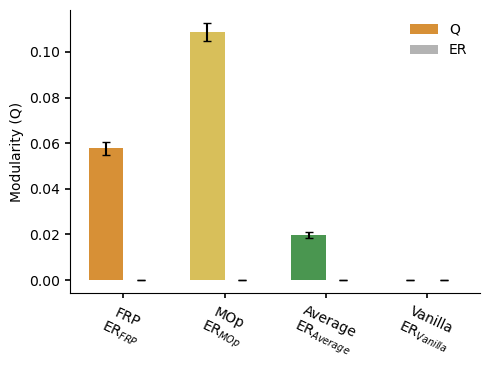

saved to: results_sw_er/fig_5c_modularity.svg

===== Paired t-test: Q vs ER =====
{'name': 'FRP: Q vs ER', 'n': 20, 'mean_a': 0.057664535730437595, 'mean_b': 5.5833314797525116e-05, 't': 18.741299247168513, 'p': 1.0346363381570012e-13, 'star': '***'}
{'name': 'MOp: Q vs ER', 'n': 20, 'mean_a': 0.10882554616462044, 'mean_b': 2.2050262195050714e-20, 't': 28.087710797677218, 'p': 6.16147596202329e-17, 'star': '***'}
{'name': 'Average: Q vs ER', 'n': 20, 'mean_a': 0.01972940115626342, 'mean_b': 1.2026755339541272e-17, 't': 17.375255131422055, 'p': 4.040781327448184e-13, 'star': '***'}


In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ======================
# 1) 输入文件
# ======================
q_path = "results_sw_er/Q_Qer_best.jsonl"
save_path = "results_sw_er/fig_5c_modularity.svg"

# ======================
# 2) 每个网络选一个阈值
# ======================
chosen_p = {
    "FRP": 0.23,
    "MOp": 0.13,
    "Average": 0.21,
}

net_order = ["FRP", "MOp", "Average"]

colors = {
    "FRP": "#d79036",
    "MOp": "#d8bf5a",
    "Average": "#4a9650",
    "Vanilla": "#8fbad3",
    "ER": "#b3b3b3",
}

# ======================
# 3) 读 q 文件
# 只取 gamma=1.0
# key = (net_type, n, p_thre)
# ======================
q_dict = {}
with open(q_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        rec = json.loads(line)
        gamma = float(rec.get("gamma", 1.0))
        if abs(gamma - 1.0) > 1e-9:
            continue
        key = (rec["net_type"], int(rec["n"]), round(float(rec["p_thre"]), 6))
        q_dict[key] = rec

# ======================
# 4) 每个网络只取 chosen_p
# ======================
records_by_net = {k: [] for k in net_order}

for net in net_order:
    p = round(float(chosen_p[net]), 6)
    ns = sorted({k[1] for k in q_dict if k[0] == net and abs(k[2] - p) < 1e-9})

    for n in ns:
        key = (net, n, p)
        if key in q_dict:
            records_by_net[net].append(q_dict[key])

# ======================
# 5) 统计函数：均值 + 标准误
# ======================
def mean_sem(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    n = vals.size
    if n == 0:
        return np.nan, np.nan
    if n == 1:
        return float(vals.mean()), 0.0
    sem = vals.std(ddof=1) / np.sqrt(n)
    return float(vals.mean()), float(sem)

# ======================
# 6) 汇总
# ======================
Q_mean, Q_sem = [], []
Q_er_mean, Q_er_sem = [], []

for net in net_order:
    recs = records_by_net[net]

    Q_obs = [r["Q_best"] for r in recs]
    Q_er  = [r["Q_ER_mean"] for r in recs]

    m, s = mean_sem(Q_obs)
    Q_mean.append(m)
    Q_sem.append(s)

    m, s = mean_sem(Q_er)
    Q_er_mean.append(m)
    Q_er_sem.append(s)

# ======================
# 7) 补 Vanilla 和 ER_Vanilla
# 都放在 0 附近
# ======================
vanilla_q = 0.0
vanilla_q_sem = 1e-4

vanilla_er_q = 0.0
vanilla_er_q_sem = 1e-4

group_labels = ["FRP", "MOp", "Average", "Vanilla"]
x = np.arange(len(group_labels))
barw = 0.34

Q_obs_all = [Q_mean[0], Q_mean[1], Q_mean[2], vanilla_q]
Q_obs_sem_all = [Q_sem[0], Q_sem[1], Q_sem[2], vanilla_q_sem]

Q_er_all = [Q_er_mean[0], Q_er_mean[1], Q_er_mean[2], vanilla_er_q]
Q_er_sem_all = [Q_er_sem[0], Q_er_sem[1], Q_er_sem[2], vanilla_er_q_sem]

obs_colors = [colors["FRP"], colors["MOp"], colors["Average"], colors["Vanilla"]]

# 打印每组样本量
for net in net_order:
    print(net, "threshold =", chosen_p[net], "n_samples =", len(records_by_net[net]))
print("Vanilla threshold = baseline, n_samples = manual")

# ======================
# 8) 画图
# ======================
fig, ax = plt.subplots(1, 1, figsize=(5.0, 3.8))

ax.bar(
    x - barw/2, Q_obs_all, barw,
    yerr=Q_obs_sem_all, capsize=3,
    color=obs_colors,
    edgecolor="none",
    label="Q"
)
ax.bar(
    x + barw/2, Q_er_all, barw,
    yerr=Q_er_sem_all, capsize=3,
    color=colors["ER"],
    edgecolor="none",
    label="ER"
)

ax.set_xticks(x)
ax.set_xticklabels(
    ["FRP\nER$_{FRP}$", "MOp\nER$_{MOp}$", "Average\nER$_{Average}$", "Vanilla\nER$_{Vanilla}$"],
    rotation=-25
)
ax.set_ylabel("Modularity (Q)")
ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(width=1.2)

plt.tight_layout()

# ===== 保存 SVG =====
plt.savefig(save_path, format="svg", bbox_inches="tight", transparent=True)

plt.show()
print("saved to:", save_path)


# ======================
# 9) 统计检验：Q vs ER（paired t-test）
# ======================
print("\n===== Paired t-test: Q vs ER =====")

for net in net_order:
    recs = records_by_net[net]

    Q_obs = [r["Q_best"] for r in recs]
    Q_er  = [r["Q_ER_mean"] for r in recs]

    rep_Q = paired_ttest_report(f"{net}: Q vs ER", Q_obs, Q_er)
    print(rep_Q)


